## wifi signal for indoor localisation ##

In [168]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler

2.1 Multi-Linear Regression Model for Indoor Localisation

In [169]:
df = pd.read_csv("Wifi_train_dataset.csv")

# finding and dropping NaN values
print(f"Initial no. of rows: {len(df)}")
print(f"NaN values:\n{df.isna().sum()}")
df.dropna()
print(f"Final no. of rows: {len(df)}")
df.head(5)

X = df["x"]
Y = df["y"]

# make RSSI, MAC into integer type
df["rssi_list"] = df["rssi"].apply(lambda x: [int(rssi) for rssi in x.split(",")])
df["mac_list"] = df["mac_addrs_idx"].apply(lambda x: [int(mac) for mac in x.split(",")])

# all beacons/routers (unique MAC addresses)
mac_unique = set()
for mac in df["mac_list"]:
    mac_unique.update(mac)
    
mac_unique = sorted(mac_unique)
print(f"{len(mac_unique)} unique MAC values: {mac_unique}")

# create a dict which maps each MAC idx to a column no.
mac_to_col = {mac: i for i, mac in enumerate(mac_unique)}
num_features = len(mac_to_col)

# making feature matrix for multiple linear regression
# preallocate matrix
X_train = np.full((len(df), num_features), -101, dtype=np.float64)        # default RSSI is -101 for undetected


for i, (rssi_list, mac_list) in enumerate(zip(df['rssi_list'], df['mac_list'])):
    for rssi, mac in zip(rssi_list, mac_list):
        # X_train is RSSI value
        X_train[i, mac_to_col[mac]] = rssi        # assigns corresponding RSSI to the right row and col (mac column)
        
# y_train is [X;Y]
y_train = df[['x', 'y']].values

print(X_train.shape)
print(y_train.shape)

Initial no. of rows: 2880
NaN values:
x                0
y                0
rssi             0
mac_addrs_idx    0
dtype: int64
Final no. of rows: 2880
562 unique MAC values: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 128, 129, 130, 131, 132, 133, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 181, 182, 183, 184, 185, 186, 187

In [170]:
# clean again just in case
nan_mask = np.isnan(y_train).any(axis=1)
print(f"Rows with NaN for (x, y): {nan_mask.sum()}")
# so no need to clean

# split data to train/validation split 80/20
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=42
)

print(f"Training set: {X_train.shape[0]} samples")
print(f"Validation set: {X_val.shape[0]} samples")

# make model and train!
model = LinearRegression()

model.fit(X_train,y_train)

# validate
y_val_pred_lr = model.predict(X_val)

# Calculate MSE for each coordinate
lr_mse_x = mean_squared_error(y_val[:,0], y_val_pred_lr[:,0])
lr_mse_y = mean_squared_error(y_val[:,1], y_val_pred_lr[:,1])
lr_mse_total = mean_squared_error(y_val, y_val_pred_lr)

print(f"MSE in x: {lr_mse_x}m")
print(f"MSE in y: {lr_mse_y}m")
print(f"Total MSE: {lr_mse_total}m")

Rows with NaN for (x, y): 0
Training set: 2304 samples
Validation set: 576 samples
MSE in x: 20.755685881831056m
MSE in y: 26.49301140422304m
Total MSE: 23.624348643027062m


2.2 Neural Network Model for Indoor Localisation

In [171]:
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

In [172]:
# normalise features to improve training 
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

# convert to tensors for NN
X_train_t = torch.FloatTensor(X_train_scaled)
y_train_t = torch.FloatTensor(y_train)
X_val_t = torch.FloatTensor(X_val_scaled)
y_val_t = torch.FloatTensor(y_val)

# DataLoader
train_loader = DataLoader(TensorDataset(X_train_t, y_train_t), batch_size=64, shuffle=True)

class IndoorNet(nn.Module):
    # make model using pytorch's nn library
    def __init__(self, input_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 512),
            nn.BatchNorm1d(512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.BatchNorm1d(256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, 128),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 2)
        )
        
    def forward(self, x):
        return self.net(x)
    
model = IndoorNet(X_train.shape[1])
criterion = nn.MSELoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [173]:
# training
for epoch in range(400):
    model.train()
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
    
    if (epoch + 1) % 20 == 0:
        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_t), y_val_t)
        print(f"Epoch {epoch+1} | Val MSE = {val_loss.item():.4f}")

Epoch 20 | Val MSE = 1468.0669
Epoch 40 | Val MSE = 1195.8398
Epoch 60 | Val MSE = 916.6287
Epoch 80 | Val MSE = 657.7103
Epoch 100 | Val MSE = 467.5026
Epoch 120 | Val MSE = 268.8288
Epoch 140 | Val MSE = 143.2251
Epoch 160 | Val MSE = 73.0993
Epoch 180 | Val MSE = 34.7102
Epoch 200 | Val MSE = 18.6455
Epoch 220 | Val MSE = 14.0016
Epoch 240 | Val MSE = 12.8512
Epoch 260 | Val MSE = 11.5656
Epoch 280 | Val MSE = 10.5720
Epoch 300 | Val MSE = 10.5377
Epoch 320 | Val MSE = 10.0528
Epoch 340 | Val MSE = 10.4756
Epoch 360 | Val MSE = 9.3066
Epoch 380 | Val MSE = 9.0688
Epoch 400 | Val MSE = 8.9157


Final MSE: 8.9157
Metric          Linear Reg      Neural Net     
MSE (X)         20.7557         8.4209         
MSE (Y)         26.4930         9.4104         
MSE (Total)     23.6243         8.9157         

Improvement: 62.3%


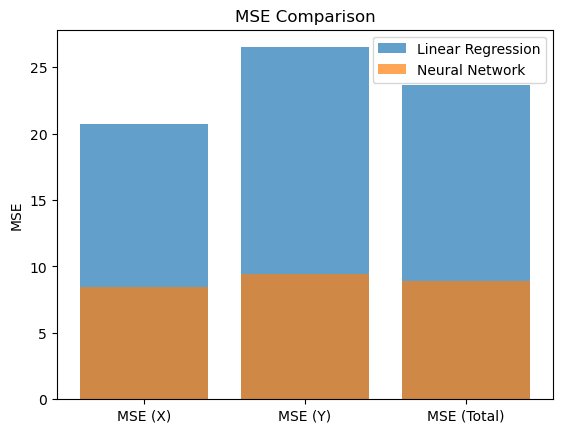

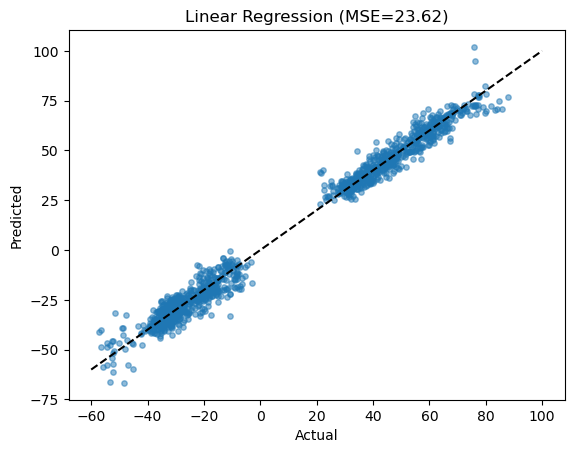

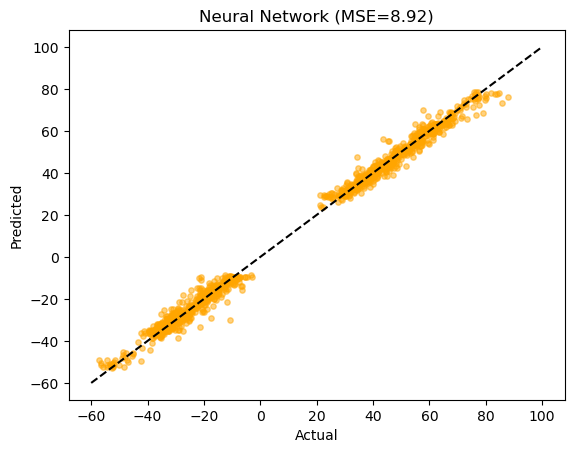

In [174]:
# final evaluation
model.eval()
with torch.no_grad():
    nn_y_pred = model(X_val_t).numpy()
    
nn_mse_x = mean_squared_error(y_val[:,0], nn_y_pred[:,0])
nn_mse_y = mean_squared_error(y_val[:,1], nn_y_pred[:,1])
nn_mse_total = mean_squared_error(y_val, nn_y_pred)
print(f"Final MSE: {nn_mse_total:.4f}")

# model comparison on validation set
print(f"{'Metric':<15} {'Linear Reg':<15} {'Neural Net':<15}")
print(f"{'MSE (X)':<15} {lr_mse_x:<15.4f} {nn_mse_x:<15.4f}")
print(f"{'MSE (Y)':<15} {lr_mse_y:<15.4f} {nn_mse_y:<15.4f}")
print(f"{'MSE (Total)':<15} {lr_mse_total:<15.4f} {nn_mse_total:<15.4f}")
print()
print(f"Improvement: {((lr_mse_total - nn_mse_total) / lr_mse_total * 100):.1f}%")

# plot the performance
# barchart
metrics = ['MSE (X)', 'MSE (Y)', 'MSE (Total)']
lr_scores = [lr_mse_x, lr_mse_y, lr_mse_total]
nn_scores = [nn_mse_x, nn_mse_y, nn_mse_total]

plt.bar(metrics, lr_scores, alpha=0.7, label='Linear Regression')
plt.bar(metrics, nn_scores, alpha=0.7, label='Neural Network')
plt.ylabel('MSE')
plt.title('MSE Comparison')
plt.legend()
plt.show()

# scatter plot
# linear reg
plt.figure()
plt.scatter(y_val, y_val_pred_lr, alpha=0.5, s=15)
plt.plot([-60, 100], [-60, 100], 'k--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Linear Regression (MSE={lr_mse_total:.2f})')
plt.show()

# neural network
plt.figure()
plt.scatter(y_val, nn_y_pred, alpha=0.5, s=15, color='orange')
plt.plot([-60, 100], [-60, 100], 'k--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(f'Neural Network (MSE={nn_mse_total:.2f})')
plt.show()


2.3 Dimensionality Reduction for Feature Visualization

In [ ]:
from sklearn.cluster import KMeans
from sklearn.manifold import TSNE

Extracted feature shape: (576, 64)


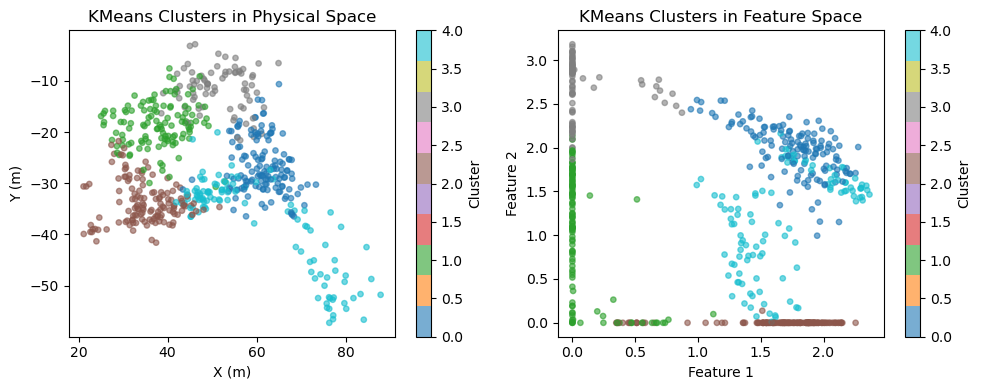

In [176]:
# i. extracting features from second to last layer (64 neurons)

class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super().__init__()
        # model.net.children() returns each layer in the Sequential block
        # [:-1] removes the final Linear(64,2) layer so we get the 64-dim features
        self.layers = list(model.net.children())[:-1]
        # *self.layers unpacks the list so Sequential gets each layer as separate args
        self.feature_net = nn.Sequential(*self.layers)
    
    def forward(self, x):
        return self.feature_net(x)

feature_extractor = FeatureExtractor(model)
feature_extractor.eval()  # set to evaluation mode (disables dropout)

# torch.no_grad() disables gradient computation since we're just extracting, not training
with torch.no_grad():
    features = feature_extractor(X_val_t).numpy()

print(f"Extracted feature shape: {features.shape}")

# clustering with KMeans (w/out labels)
n_clusters = 5
kmeans = KMeans(n_clusters=n_clusters, random_state=42)
clusters = kmeans.fit_predict(features)  # fit and return cluster labels

# visualise clusters against actual positions
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
# c=clusters colours each point by its cluster assignment
plt.scatter(y_val[:, 0], y_val[:, 1], c=clusters, cmap='tab10', alpha=0.6, s=15)
plt.xlabel('X (m)')
plt.ylabel('Y (m)')
plt.title('KMeans Clusters in Physical Space')
plt.colorbar(label='Cluster')

plt.subplot(1, 2, 2)
plt.scatter(features[:, 0], features[:, 1], c=clusters, cmap='tab10', alpha=0.6, s=15)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.title('KMeans Clusters in Feature Space')
plt.colorbar(label='Cluster')

plt.tight_layout()
plt.show()

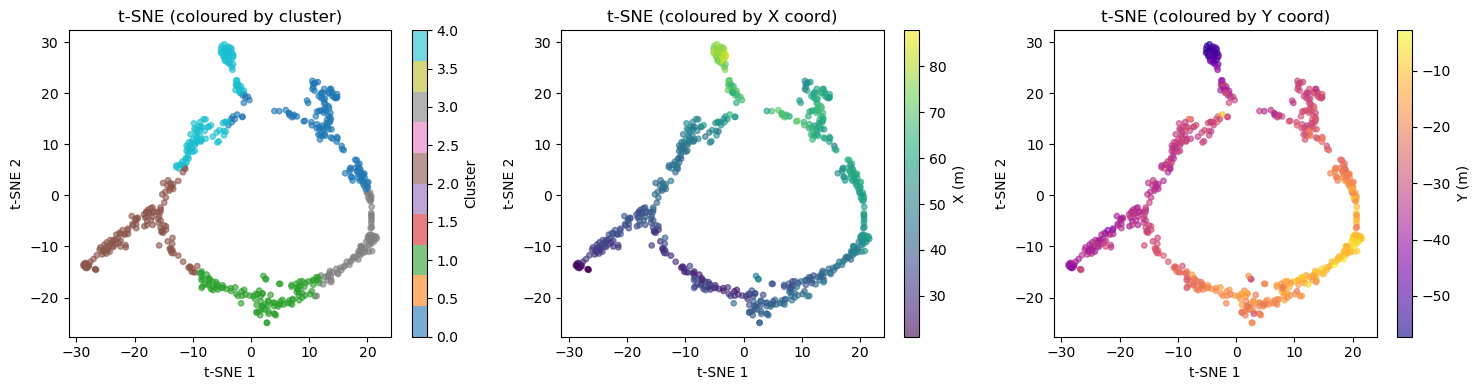

In [ ]:
# ii. dim reduction using t-SNE
# t-SNE for non-linearity, preserves local structure (neighbours stay neighbours)
tsne = TSNE(n_components=2, random_state=42, perplexity=30)     # to 2D
features_tsne = tsne.fit_transform(features)

# visualise
# t-SNE coloured by clusters
plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=clusters, cmap='tab10', alpha=0.6, s=15)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE (by cluster)')
plt.colorbar(label='Cluster')

# t-SNE coloured by X coordinate
plt.subplot(1, 3, 2)
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=y_val[:, 0], cmap='viridis', alpha=0.6, s=15)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE (by X coord)')
plt.colorbar(label='X (m)')

# t-SNE coloured by Y coordinate
plt.subplot(1, 3, 3)
plt.scatter(features_tsne[:, 0], features_tsne[:, 1], c=y_val[:, 1], cmap='plasma', alpha=0.6, s=15)
plt.xlabel('t-SNE 1')
plt.ylabel('t-SNE 2')
plt.title('t-SNE (by Y coord)')
plt.colorbar(label='Y (m)')

plt.tight_layout()
plt.show()